# Practical session 2 - Practise with classic libraries

Students (pair):
- [Louise Amaladasse]([link](https://github.com/louiseamaladasse-a11y))
- [Zineb Ferhoun]([link](https://github.com/zineb-f))

**Useful references for this lab**:

[1] `numpy`: [lecture notes (1.4.1-1.4.2)](https://scipy-lectures.org/intro/numpy/index.html) and [documentation](https://numpy.org/doc/stable/)

[2] `pandas`: [documentation](https://pandas.pydata.org/docs/getting_started/index.html), [quick tutorial](https://pandas.pydata.org/pandas-docs/version/0.15/10min.html)

[3] `matplotlib`: [lecture notes (1.5)](https://scipy-lectures.org/intro/matplotlib/index.html) and [documentation](https://matplotlib.org/)

[4] `h5py`: [quick start guide](http://docs.h5py.org/en/stable/quick.html#quick)

## <a name="content">Contents</a>
- [Exercise 1: Computing basic statistics](#ex1)
- [Exercise 2: Random variables and histograms](#ex2)
- [Exercise 3: Discrete isotropic total variation](#ex3)
---

In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## <a name="ex1">Exercise 1: Random variables and histograms</a>

In this exercise, we are interested in generating samples from the Gamma distribution $\mathcal{G}(\alpha,\beta)$, of probability density function (pdf)

\begin{equation}
    p(x) = \frac{\beta^\alpha}{\Gamma(\alpha)} x^{\alpha-1} \exp(-\beta x) \mathbb{1}_{\mathbb{R}_+^*}(x),
\end{equation}

and displaying their histogram. In the following, we consider $(\alpha, \beta) = (9, 2)$.

1\. Set the random seed to a fixed value for reproducibility, and biefly check your instruction works as intended.
> Hint: you may take a look at the following pages: [random module](https://numpy.org/doc/stable/reference/random/index.html?highlight=random#module-numpy.random), [random generator](https://numpy.org/doc/stable/reference/random/generator.html).

**Answer**:

In [24]:
import random as rd

# On utilise la même "graine" pour générer les deux nombres aléatoires
# x1 et x2

rd.seed(42)
x1 = rd.random()

rd.seed(42)
x2 = rd.random()

print("x1 =", x1)
print("x2 =",x2)
print(x1 == x2)

x1 = 0.6394267984578837
x2 = 0.6394267984578837
True


2\. Generate $\approx 10^5$ samples in a vector. Save the vector in a file, `samples.hdf5` or `samples.npy`.
> Warning / hint: 
> - take a careful look at the [documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.gamma.html?highlight=gamma#numpy.random.gamma) (multiple conventions exist for the definition of the pdf underlying the distribution...);
> - to save data in a `npy` file, take a look at the example reported in the [Numpy documentation](https://numpy.org/doc/stable/reference/generated/numpy.save.html);
> - to save data in a `.h5` file, take a quick look at the [documentation here](https://docs.h5py.org/en/stable/quick.html#quick).

**Answer**:

In [25]:
# imports

import numpy as np
import random as rd

# Ici, scale = 1/beta pour la loi gamma de Numpy

alpha = 9
beta = 2

samples = np.random.gamma(shape=alpha, scale=1/beta, size=10**5)



# sauvegarde du fichier
np.save("samples.npy", samples)

3\. Estimate an histogram of this distribution for a well chosen set of bins, and display it.
> Warnings: 
> - make sure the [histogram](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html?highlight=hist#matplotlib.pyplot.hist) corresponds to a probability density function (pdf);
> - do not forget to include a proper title with names for the axes.

**Answer**:

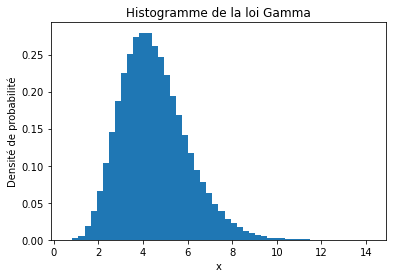

In [26]:
import matplotlib.pyplot as plt

plt.hist(samples, bins=50, density=True)
plt.title("Histogramme de la loi Gamma")
plt.xlabel("x")
plt.ylabel("Densité de probabilité")

plt.show()

4\. Overlay the probability density function on the histogram and compare these in a few words. Save the resulting picture in `.png` format.
> Hint: 
> - take a look at the `scipy` [documentation](https://docs.scipy.org/doc/scipy/reference/stats.html) to avoid implementing the pdf from scratch;
> - return the bins in which the histogram is computed, and evaluate the pdf on those points.

**Answer**:

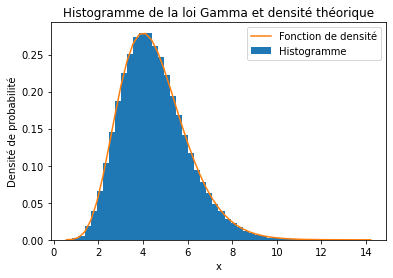

In [32]:
import matplotlib.pyplot as plt
from scipy.stats import gamma

alpha = 9
beta = 2

# On récupère les bins utilisées pour l'histogramme
_, bins, _ = plt.hist(samples, bins=50, density=True, label = "Histogramme")

# densité
pdf = gamma.pdf(bins, a = alpha, scale=1/beta)

# courbe tracée par dessus
plt.plot(bins, pdf, label = 'Fonction de densité')
plt.title("Histogramme de la loi Gamma et densité théorique")
plt.xlabel("x")
plt.ylabel("Densité de probabilité")
plt.legend()

plt.savefig("histogramme_gamma.png")
# plt.savefig("histogramme_gamma.png", bbox_inches="tight", dpi=150)
plt.show()

La courbe de densité théorique est cohérente avec le tracé de l'histogramme

---
## <a name="ex2">Exercise 2: Basic statistics with `pandas`</a>

In this second exercise, we focus on computing basic statistics, and applying linear regression to a small data set. These data are gathered in the following table, which gives the infant mortality (`X`) and the gross national product per inhabitant (`Y`) of 12 european countries :

| `X` | 190 | 128 | 180 | 212 | 56 | 192 | 68 | 98 | 110 | 197 | 181 | 233 |
|-----|-----|-----|-----|----|-----|----|----|-----|-----|-----|-----|-----|
| `Y` |  24 |  28 |  24 | 19 |  37 | 22 | 34 |  25 |  36 |  24 |  20 |  18 |

1\. For `X `and `Y`, compute the median, mean, variance and standard deviation. The data points have already been entered into a `.csv` file stored in `data/data.csv`.
> Hint: 
> - you can directly use `pandas` to load the data into a `DataFrame` ([`pd.read_csv`](https://pandas.pydata.org/docs/reference/frame.html));
> - take a look at the built-in operations available for `DataFrame` objects ([documentation](https://pandas.pydata.org/docs/reference/frame.html));
> - to display a `DataFrame` `f`:
> ```python 
> from IPython.display import display
> display(df)
> ```
> - sort the `DataFrame` with respect to the value of `X` (see [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html#pandas.DataFrame.sort_values)) This will be useful for question 3.

**Answer**:

In [34]:
import pandas as pd


df = pd.read_csv("data/data.csv")


display(df)

c:\Users\Zineb\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,X,Y
0,190,24
1,128,28
2,180,24
3,212,19
4,56,37
5,192,22
6,68,34
7,98,25
8,110,36
9,197,24


In [37]:
x = df["X"]

medianx = x.median()
meanx = x.mean()
variancex = x.var()
stdx = x.std()

y = df["Y"]

mediany = y.median()
meany = y.mean()
variancey = y.var()
stdy = y.std()

print("X (Mortalité infantile): ")
print("Median =", medianx)
print("Mean =", meanx)
print("Variance =", variancex)
print("Standard deviation =", stdx)

print("\nY (Produit national brut par habitant) :")
print("Median =", mediany)
print("Mean =", meany)
print("Variance =", variancey)
print("Standard deviation =", stdy)


X (Mortalité infantile): 
Median = 180.5
Mean = 153.75
Variance = 3486.0227272727275
Standard deviation = 59.04255014201815

Y (Produit national brut par habitant) :
Median = 24.0
Mean = 25.916666666666668
Variance = 42.446969696969695
Standard deviation = 6.5151338970868204


In [ ]:
# On trie le dataframe selon x
df = df.sort_values("X")
display(df)

,X,Y
4,56,37
6,68,34
7,98,25
8,110,36
1,128,28
2,180,24
10,181,20
0,190,24
5,192,22
9,197,24


2\. Give the equation of the regression line of `Y` as a function of `X`.
> Hint: 
> - take a look at the functionalities available in `numpy` (e.g., `np.polyfit` and `np.polyval`);
> - if needed, note that you can retrieve the data from the resulting `pandas` `DataFrame` with the `to_numpy()` method.

**Answer**:

In [39]:
import numpy as np

x = df["X"].to_numpy()
y = df["Y"].to_numpy()

a, b = np.polyfit(x, y, 1)

print("a =", a)
print("b =", b)
print(f" Equation de régression linéaire : Y = {a:.3f} X + {b:.3f}")

a = -0.0981647488346319
b = 41.009496799991325
 Equation de régression linéaire : Y = -0.098 X + 41.009


3\. Display the cloud of points and the regression line $Y = f(X)$ on the same figure. Save the figure in `.png` format.

**Answer**:

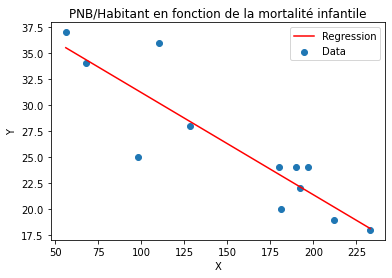

In [ ]:
import numpy as np

x = df["X"].to_numpy()
y = df["Y"].to_numpy()



y_reg = np.polyval([a,b], df["X"])
plt.scatter(x,y, label ="Data")

# Ici on peut utiliser directement x en abscisse car X est déjà trié (intérêt de la question 1)

plt.title("PNB/Habitant en fonction de la mortalité infantile")
plt.plot(x, y_reg, color = 'red' ,label="Regression")

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()

plt.show()


---
## <a name="ex3">Exercise 3: Discrete isotropic total variation</a>

This exercise is devoted to the computation of the discrete isotropic total variation (TV) of an input matrix $\mathbf{X} = [\mathbf{x}_n]_{1 \leq n \leq N} \in\mathbb{C}^{M \times N}$, which is particularly useful in Bayesian inference (e.g., for inverse problems) to promote piece-wise smooth solutions. The TV is defined as

\begin{equation*}
    \text{TV}(\mathbf{X}) = \Vert D(\mathbf{X}) \Vert_{1,2} = \sum_{m=1}^M \sum_{n=1}^N \sqrt{[\mathbf{XD}_h]^2_{m,n} + [\mathbf{D}_v\mathbf{X}]^2_{m,n}},
\end{equation*}

where $[\mathbf{Z}]_{m,n}$ denotes the elements in position $(m,n)$ of the matrix $\mathbf{Z}$,

\begin{align*}
    D(X) &= (\mathbf{XD}_h, \mathbf{D}_v\mathbf{X}) \in \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} \\
    %
    \mathbf{XD}_h &= [\mathbf{x}_2-\mathbf{x}_1, \dotsc, \mathbf{x}_N-\mathbf{x}_{N-1}, \mathbf{0}_M] \in \mathbb{C}^{M\times N} \\
    %
    \mathbf{D}_v\mathbf{X} &= [\tilde{\mathbf{x}}_2^T-\tilde{\mathbf{x}}^T_1, \dotsc, \tilde{\mathbf{x}}^T_M-\tilde{\mathbf{x}}^T_{M-1}, \mathbf{0}_N]^T \in \mathbb{C}^{M\times N},
\end{align*}

$\mathbf{x}_n \in \mathbb{C}^{M}$ is the $n$-th column of $\mathbf{X}$, and $\tilde{\mathbf{x}}_m \in \mathbb{C}^{1\times N}$ is the $m$-th row of $\mathbf{X}$. 
The linear operator $D: \mathbb{C}^{M\times N} \rightarrow \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} $ is the discrete gradient operator. The adjoint of $D$, $D^*: \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} \rightarrow \mathbb{C}^{M\times N}$, is given by

\begin{align*}
    (\forall \mathbf{Y} = (\mathbf{Y}_h,\mathbf{Y}_v)), \quad D^*(\mathbf{Y}) &= \mathbf{Y}_h\mathbf{D}^*_h + \mathbf{D}^*_v\mathbf{Y}_v \\
    %
    \mathbf{Y}_h\mathbf{D}^*_h &= \big[-\mathbf{y}_{h,1},- [\mathbf{y}_{h,n}-\mathbf{y}_{h,n-1}]_{2 \leq n \leq N-1}, \mathbf{y}_{h, N-1} \big] \\
    %
    \mathbf{D}^*_v\mathbf{Y}_v &= \big[-\tilde{\mathbf{y}}_{v,1}^T,- [\tilde{\mathbf{y}}_{v,m}^T-\tilde{\mathbf{y}}^T_{v,m-1}]_{2 \leq m \leq M-1}, \tilde{\mathbf{y}}^T_{v, M-1} \big]^T
\end{align*}

where $\mathbf{y}_{h,n}$ is the $n$-th column of $\mathbf{Y}_h$, and $\tilde{\mathbf{x}}_{v,m}$ is the $m$-th row of $\mathbf{Y}_v$.

1\. Using `numpy`, implement a function `gradient2D` to compute the 2D discrete gradient operator $D$ applied to a matrix $\mathbf{X}\in\mathbb{C}^{M \times N}$ (no for loops!). Trigger an error message whenever the input array has more than 2 dimensions. If not clear from the implementation, add a few short comments to explain your code.

> Hint: 
> - to trigger an error, you can for instance use an `assert` statement, or raise an [exception (e.g., `AssertionError`)](https://docs.python.org/3/library/exceptions.html);
> - only a few operations are needed: computing vertical differences, horizontal differences, and possibly a concatenation of matrices into a single tensor (= n-dimensional array);
> - possibly useful functions: `np.diff`, `np.c_`, `np.r_` (or `np.concatenate`). 

**Answer**:

In [16]:
from fonctions import gradient2D

In [17]:
X = [
    [1,2,3],
    [4,3,6]]

gradient2D(X)

array([[[ 1.,  1.,  0.],
        [-1.,  3.,  0.]],

       [[ 3.,  1.,  3.],
        [ 0.,  0.,  0.]]])

2\. Implement a unit-test to validate the behaviour of the `gradient2D` function. For instance, you can check the format of the output, and test the result when the function is evaluated on a constant matrix (for both a square and a non-square input matrix). Run the unit-test from the present Jupyter notebook.

**Answer**:

In [18]:
!pytest -v test_fonctions.py

============================= test session starts =============================
platform win32 -- Python 3.8.5, pytest-6.1.1, py-1.9.0, pluggy-0.13.1 -- C:\Users\Zineb\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\Zineb\Desktop\école\G3\Parcours\python\python_sdia_binome\Labs\Lab2
collecting ... collected 5 items

test_fonctions.py::test_square_constant_matrix PASSED                    [ 20%]
test_fonctions.py::test_non_square_constant_matrix PASSED                [ 40%]
test_fonctions.py::test_wrong_dimension PASSED                           [ 60%]
test_fonctions.py::test_tv_constant_matrix PASSED                        [ 80%]
test_fonctions.py::test_gradient2D_adjoint PASSED                        [100%]

============================== warnings summary ===============================
..\..\..\..\..\..\..\..\anaconda3\lib\site-packages\pyreadline\py3k_compat.py:8
  C:\Users\Zineb\anaconda3\lib\site-packages\pyreadline\py3k_compat.py:8: DeprecationWarning: Using or imp

3\. Document the function `gradient2D` with an appropriate docstring (see Lab 1).

**Answer**:

In [19]:
help(gradient2D)

Help on function gradient2D in module fonctions:

gradient2D(X)
    Compute the 2D discrete gradient of a matrix.
    
    Parameters
    ----------
    X : array_like
        Input matrix of shape (M, N).
    
    Returns
    -------
    numpy.ndarray
        Gradient array of shape (2, M, N), where the first component
        contains the horizontal differences and the second component
        contains the vertical differences.
    
    Raises
    ------
    AssertionError
        If X has more than two dimensions.



4\. Using 1., define a function `tv` to compute $\text{TV}(\mathbf{X})$, $\mathbf{X}\in\mathbb{C}^{M \times N}$. Write a unit-test and document your function.

**Answer**:

In [5]:
def tv(X):
    """
    Compute the discrete isotropic total variation of a matrix.

    Parameters
    ----------
    X : array_like
        Input matrix of shape (M, N).

    Returns
    -------
    float
        Total variation of X.
    """

    G = gradient2D(X)

    return np.sum(np.sqrt(G[0]**2 + G[1]**2))


In [9]:
from fonctions import tv

In [11]:
!pytest -v

============================= test session starts =============================
platform win32 -- Python 3.8.5, pytest-6.1.1, py-1.9.0, pluggy-0.13.1 -- C:\Users\Zineb\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\Zineb\Desktop\école\G3\Parcours\python\python_sdia_binome\Labs\Lab2
collecting ... collected 4 items

test_fonctions.py::test_square_constant_matrix PASSED                    [ 25%]
test_fonctions.py::test_non_square_constant_matrix PASSED                [ 50%]
test_fonctions.py::test_wrong_dimension PASSED                           [ 75%]
test_fonctions.py::test_tv_constant_matrix PASSED                        [100%]

============================== warnings summary ===============================
..\..\..\..\..\..\..\..\anaconda3\lib\site-packages\pyreadline\py3k_compat.py:8
  C:\Users\Zineb\anaconda3\lib\site-packages\pyreadline\py3k_compat.py:8: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecat

5\. Implement a function `gradient2D_adjoint` to compute $D^*(\mathbf{Y})$, the adjoint of the 2D discrete gradient operator $D$ applied to $\mathbf{Y}\in\mathbb{C}^{M \times N}\times \mathbb{C}^{M \times N}$. Add a few short comments to explain your code whenever appropriate.

**Answer**:

In [ ]:
def gradient2D_adjoint(Y):

    dim, m, n = np.shape(Y)



    # On sépare les deux matrices en entrée
    Y_h = Y[0]
    Y_v = Y[1]

    # Horizontal
    D_h = -np.diff(
        np.concatenate(
            (np.zeros((m, 1)), Y_h[:, :-1], np.zeros((m, 1))), # On reconstruit une matrice de la forme [0, y_1, ..., y_(n-1), 0] qui nous permet d'utiliser np.diff
            # il suffit de multiplier par -1 pour obtenir le résultat voulu
            axis=1
        ),
        axis=1
    )

    # Vertical
    D_v = -np.diff(
        np.concatenate(
            (np.zeros((1, n)), Y_v[:-1, :], np.zeros((1, n))),
            axis=0
        ),
        axis=0
    )

    return D_h + D_v

6\. Implement a unit-test to validate `gradient2D_adjoint`, e.g., by checking the size of the output from the function and verifying that `gradient2D_adjoint` is adjoint to `gradient2D`, i.e., for any $\mathbf{X}\in\mathbb{C}^{M \times N}$ and $\mathbf{Y}\in\mathbb{C}^{M \times N}\times \mathbb{C}^{M \times N}$:

\begin{equation}
    \forall \mathbf{X} \in \mathbb{C}^{M \times N}, \mathbf{Y} = (\mathbf{Y}_h, \mathbf{Y}_v) \in \mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}, \;
    %
    \langle D(\mathbf{X}), \mathbf{Y} \rangle_{\mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}} = \langle \mathbf{X}, D^*(\mathbf{Y}) \rangle_{\mathbb{C}^{M \times N}}, 
\end{equation}

where 

\begin{align}
    &\forall \mathbf{U}, \mathbf{V} \in \mathbb{C}^{M \times N}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{M \times N}} = \text{Tr}(\mathbf{U}^H \mathbf{V}) = \sum_{m=1}^M \sum_{n=1}^N u_{m,n}^* v_{m,n}, \\
    &\forall \mathbf{U} = (\mathbf{U}_h, \mathbf{U}_v), \mathbf{V} = (\mathbf{V}_h, \mathbf{V}_v) \in \mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}} = \langle \mathbf{U}_h, \mathbf{V}_h \rangle_{\mathbb{C}^{M \times N}} + \langle \mathbf{U}_v, \mathbf{V}_v \rangle_{\mathbb{C}^{M \times N}}.
\end{align}

> Hint: to verify `gradient2D_adjoint` is the adjoint of `gradient2D`, evaluate the scalar products above for randomly drawn matrices. Set the random generator to a known state for reproducibility (see [Exercise 1](#ex1)).

**Answer**:

In [14]:
!pytest -v

============================= test session starts =============================
platform win32 -- Python 3.8.5, pytest-6.1.1, py-1.9.0, pluggy-0.13.1 -- C:\Users\Zineb\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\Zineb\Desktop\école\G3\Parcours\python\python_sdia_binome\Labs\Lab2
collecting ... collected 5 items

test_fonctions.py::test_square_constant_matrix PASSED                    [ 20%]
test_fonctions.py::test_non_square_constant_matrix PASSED                [ 40%]
test_fonctions.py::test_wrong_dimension PASSED                           [ 60%]
test_fonctions.py::test_tv_constant_matrix PASSED                        [ 80%]
test_fonctions.py::test_gradient2D_adjoint PASSED                        [100%]

============================== warnings summary ===============================
..\..\..\..\..\..\..\..\anaconda3\lib\site-packages\pyreadline\py3k_compat.py:8
  C:\Users\Zineb\anaconda3\lib\site-packages\pyreadline\py3k_compat.py:8: DeprecationWarning: Using or imp

[Bonus, **optional**]. Generalize the `gradient2D` to any number of dimensions ($\mathbf{X} \in \mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}$), i.e., by returning tensors obtained by computing differences along each of its dimensions.
> Hint: 
> - you may use a loops here, and/or list comprehension. Using slice objects (see [np.s_](https://numpy.org/doc/stable/reference/generated/numpy.s_.html?highlight=s_#numpy.s_) and [this page](https://stackoverflow.com/questions/24432209/python-index-an-array-using-the-colon-operator-in-an-arbitrary-dimension)) can be an interesting option.
>
> - the definition of the scalar product above can be extended to the case of tensors as follows:
> \begin{equation}
    \mathbf{U}, \mathbf{V} \in \mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}} =  \sum_{n_1 = 1}^{N_1}  \sum_{n_2 = 1}^{N_2} \dotsc \sum_{n_p = 1}^{N_p} u_{n_1, n_2, \dotsc, n_p}^* v_{n_1, n_2, \dotsc, n_p}   
\end{equation}

**Answer**:

In [ ]:
# your code

## Reference

```bibtex
@article{condat:hal-01309685,
  TITLE = {{Discrete Total Variation: New Definition and Minimization}},
  AUTHOR = {Condat, Laurent},
  URL = {https://hal.archives-ouvertes.fr/hal-01309685},
  JOURNAL = {{SIAM Journal on Imaging Sciences}},
  PUBLISHER = {{Society for Industrial and Applied Mathematics}},
  VOLUME = {10},
  NUMBER = {3},
  PAGES = {1258--1290},
  YEAR = {2017},
  MONTH = Aug,
  DOI = {10.1137/16M1075247},
  KEYWORDS = { variational image processing ; total variation ;  finite-difference schemes ;  coarea formula},
  PDF = {https://hal.archives-ouvertes.fr/hal-01309685v3/file/Condat-newTV.pdf},
  HAL_ID = {hal-01309685},
  HAL_VERSION = {v3},
}
```
